# Post-Inhibitory Rebound Bursting

Thalamic relay neurons can fire a **rebound burst** after a period of hyperpolarization. The low-threshold T-type calcium current inactivates at rest, but a sustained hyperpolarizing input removes that inactivation. When the hyperpolarization ends, the T-current activates transiently and drives a brief burst of spikes — even though the net input is now zero.

In [1]:
import brainstate
import braintools
import brainunit as u
import numpy as np
import matplotlib.pyplot as plt
import braincell

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## A cell with a T-type calcium current

The key ingredient is the low-threshold T-type calcium channel (`CaT_HM1992`); `HCN_HM1992` (the H-current) sets a realistic resting potential, and the high-threshold calcium current shapes the burst.

In [2]:
class ThalamicCell(braincell.SingleCompartment):
    """Thalamic-relay-style cell with a low-threshold T-type Ca current."""
    def __init__(self, size, solver='ind_exp_euler'):
        super().__init__(size, V_initializer=braintools.init.Constant(-65. * u.mV),
                         V_th=20. * u.mV, solver=solver)
        self.na = braincell.ion.SodiumFixed(size, E=50. * u.mV)
        self.na.add(INa=braincell.channel.Na_Ba2002(size, V_sh=-30 * u.mV))
        self.k = braincell.ion.PotassiumFixed(size, E=-90. * u.mV)
        self.k.add(IKL=braincell.channel.K_Leak(size, g_max=0.01 * (u.mS / u.cm ** 2)))
        self.k.add(IDR=braincell.channel.KDR_Ba2002(size, V_sh=-30. * u.mV))
        self.ca = braincell.ion.CalciumDetailed(size, C_rest=5e-5 * u.mM,
                                                tau=10. * u.ms, d=0.5 * u.um)
        self.ca.add(ICaT=braincell.channel.CaT_HM1992(size, g_max=2.1 * (u.mS / u.cm ** 2)))
        self.ca.add(ICaHT=braincell.channel.CaHT_HM1992(size, g_max=3.0 * (u.mS / u.cm ** 2)))
        self.Ih = braincell.channel.HCN_HM1992(size, g_max=0.01 * (u.mS / u.cm ** 2), E=-43 * u.mV)
        self.IL = braincell.channel.IL(size, g_max=0.0075 * (u.mS / u.cm ** 2), E=-70 * u.mV)

## Apply a hyperpolarizing step, then release

We inject a hyperpolarizing current density of -2 uA/cm^2 for the first 200 ms, then switch to zero. The current is a function of time `t`, selected with `u.math.where`.

In [3]:
cell = ThalamicCell(1)
cell.init_state()

def I_of_t(t):
    return u.math.where(t < 200. * u.ms,
                        -2. * u.uA / u.cm ** 2,
                        0. * u.uA / u.cm ** 2)

def step(t):
    with brainstate.environ.context(t=t):
        cell.update(I_of_t(t))
    return cell.V.value, cell.spike.value

with brainstate.environ.context(dt=0.01 * u.ms):
    times = u.math.arange(0. * u.ms, 500. * u.ms, brainstate.environ.get_dt())
    vs, spikes = brainstate.transform.for_loop(step, times)

spike_times = np.asarray(times[u.math.squeeze(spikes) > 0] / u.ms)
rebound = spike_times[spike_times > 200.]
print('spikes after release (ms):', np.round(rebound[:10], 1).tolist())

spikes after release (ms): [266.5, 275.79998779296875, 277.8999938964844, 280.29998779296875, 282.8999938964844, 286.0, 289.70001220703125, 294.6000061035156, 302.70001220703125]


## Visualize the rebound burst

During the hyperpolarizing step the cell is silent and below rest; on release it overshoots and fires a short, high-frequency burst before settling.

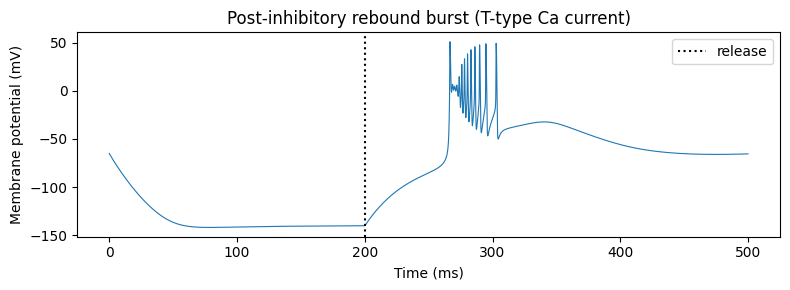

In [4]:
plt.figure(figsize=(8, 3))
plt.plot(times / u.ms, u.math.squeeze(vs) / u.mV, linewidth=0.8)
plt.axvline(200., color='k', linestyle=':', label='release')
plt.xlabel('Time (ms)'); plt.ylabel('Membrane potential (mV)')
plt.title('Post-inhibitory rebound burst (T-type Ca current)')
plt.legend(); plt.tight_layout(); plt.show()